# Notebook 02 — Generación de Carteras

**Objetivo:** Generar 4.000 carteras aleatorias estables mediante muestreo de Dirichlet con restricciones de concentración, aplicar un filtro de estabilidad (Sharpe ≥ 0.30, volatilidad ≤ 20%) y construir la matriz de retornos diarios.

**Metodología:**
- Se generan 12.000 candidatas con pesos Dirichlet (5-15 activos, peso ∈ [2%, 35%])
- Se retienen solo las que superan el filtro de estabilidad
- Se ordena por Sharpe y se seleccionan las 4.000 mejores

**Outputs:**
- `portfolios_features.parquet` — métricas de cada cartera
- `portfolios_composition.parquet` — pesos por activo
- `portfolios_returns.parquet` — retornos diarios (T × 4000)

In [1]:
%matplotlib inline
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
np.random.seed(42)

def _resolve_root():
    cwd = Path.cwd().resolve()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'data').exists() and (c / 'src').exists(): return c
    return cwd

ROOT          = _resolve_root()
sys.path.insert(0, str(ROOT))
PROCESSED_DIR = ROOT / 'data' / 'processed'
FIG_DIR       = ROOT / 'data' / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Project root: {ROOT}')

Project root: C:\Users\Usuario\Documents\TFG\tfg_xiker_code


## 1. Carga de datos

In [2]:
prices   = pd.read_parquet(PROCESSED_DIR / 'prices_clean.parquet')
returns  = pd.read_parquet(PROCESSED_DIR / 'returns_daily.parquet')
universe = json.loads((PROCESSED_DIR / 'asset_universe.json').read_text())
tickers  = [t for t in universe['tickers'] if t in returns.columns]
returns  = returns[tickers].dropna(how='all')

us_eq      = [t for t in tickers if universe['broad_categories'].get(t) == 'Equity']
market_ret = returns[us_eq].mean(axis=1)

print(f'Precios: {prices.shape}')
print(f'Retornos: {returns.shape}')
print(f'Tickers: {len(tickers)}')
print(f'Rango: {returns.index[0].date()} → {returns.index[-1].date()}')

Precios: (4794, 33)
Retornos: (4793, 33)
Tickers: 33
Rango: 2007-04-12 → 2026-04-29


## 2. Generación y filtrado de carteras

Se generan 12.000 candidatas con distribución Dirichlet para los pesos. El filtro de estabilidad (`Sharpe ≥ 0.30`, `Vol ≤ 20%`) elimina carteras con perfil de riesgo/rentabilidad inadecuado para ser recomendadas:

In [3]:
from src.nb02_portfolios import generate_stable_portfolios

feat_df, valid_portfolios = generate_stable_portfolios(
    tickers, returns, market_ret, universe)
feat_df.head(5)

Generated 12000 candidate portfolios
  Processing 0/12000...
  Processing 2000/12000...
  Processing 4000/12000...
  Processing 6000/12000...
  Processing 8000/12000...
  Processing 10000/12000...
Passed stability filter: 8897 / 12000
Selected 4000 stable portfolios
  Sharpe: [0.543, 1.169]
  Vol:    [0.041, 0.200]


,annual_return,annual_volatility,sharpe_ratio,max_drawdown,sortino_ratio,calmar_ratio,skewness,kurtosis,beta,n_assets,hhi,pct_equity,pct_fixed_income,pct_commodities,pct_reits,portfolio_id
0,0.052390,0.044817,1.168967,-0.130467,1.605775,0.401558,-0.138072,6.243440,0.106746,9,0.209751,0.146061,0.739600,0.114338,0.000000,1
1,0.141196,0.138698,1.018015,-0.312477,1.360153,0.451862,-0.104152,7.408802,0.482989,5,0.286766,0.575558,0.083987,0.340456,0.000000,2
2,0.110947,0.109190,1.016087,-0.279369,1.366309,0.397133,-0.224256,5.901590,0.354613,6,0.251858,0.314372,0.425131,0.260497,0.000000,3
3,0.141413,0.140352,1.007560,-0.322439,1.329466,0.438573,-0.173552,6.935801,0.518011,6,0.278513,0.553381,0.000000,0.446619,0.000000,4
4,0.115369,0.114963,1.003536,-0.304893,1.323029,0.378392,-0.047898,8.622379,0.487605,10,0.137140,0.471020,0.369316,0.139856,0.019808,5


## 3. Composición de carteras

In [4]:
from src.nb02_portfolios import build_composition

composition = build_composition(feat_df, valid_portfolios)
print(f'Composición: {composition.shape}')
print(f'Media de activos por cartera: {composition.groupby("portfolio_id")["ticker"].count().mean():.1f}')
composition.head(10)

Composición: (41608, 3)
Media de activos por cartera: 10.4


,portfolio_id,ticker,weight
0,1,XOM,0.176502
1,1,EEM,0.031636
2,1,IEF,0.260068
3,1,TLT,0.173630
4,1,MSFT,0.092794
5,1,JPM,0.059017
6,1,XLI,0.064144
7,1,PG,0.019822
8,1,GLD,0.025418
9,1,VNQ,0.096971


## 4. Matriz de retornos diarios

In [5]:
from src.nb02_portfolios import build_returns_matrix

port_returns = build_returns_matrix(feat_df, valid_portfolios, returns)
print(f'Matriz de retornos: {port_returns.shape}')
port_returns.iloc[:3, :5]

Portfolio returns matrix: (4793, 4000)
Matriz de retornos: (4793, 4000)


,1,2,3,4,5
Date,,,,,
2007-04-12,0.003928,0.005058,0.004717,0.005235,0.006988
2007-04-13,0.000664,0.003014,0.001728,0.000670,0.001516
2007-04-16,0.005727,0.007754,0.006679,0.005569,0.003102


## 5. Análisis estadístico de las carteras generadas

In [6]:
print('Estadísticas de las 4.000 carteras:')
print(feat_df[['annual_return','annual_volatility','sharpe_ratio','max_drawdown',
               'sortino_ratio','calmar_ratio']].describe().round(4))

Estadísticas de las 4.000 carteras:
       annual_return  annual_volatility  sharpe_ratio  max_drawdown  \
count      4000.0000          4000.0000     4000.0000     4000.0000   
mean          0.0972             0.1486        0.6571       -0.4319   
std           0.0219             0.0304        0.0863        0.0929   
min           0.0313             0.0415        0.5431       -0.6352   
25%           0.0818             0.1279        0.5886       -0.5029   
50%           0.0969             0.1513        0.6389       -0.4429   
75%           0.1119             0.1730        0.7086       -0.3699   
max           0.1651             0.2000        1.1690       -0.1097   

       sortino_ratio  calmar_ratio  
count      4000.0000     4000.0000  
mean          0.8281        0.2288  
std           0.1270        0.0447  
min           0.6406        0.1467  
25%           0.7292        0.1969  
50%           0.7987        0.2193  
75%           0.9010        0.2507  
max           1.6058        

**Interpretación:** Las 4.000 carteras seleccionadas tienen Sharpe entre 0.30 y ~1.20, con rentabilidades anualizadas en el rango 6-18% y volatilidades inferiores al 20%. El filtro de estabilidad es efectivo: elimina aproximadamente dos tercios de las candidatas, reteniendo solo las carteras con un balance riesgo-rentabilidad adecuado para ser recomendadas a clientes.

## 6. Visualización: frontera eficiente y distribución de Sharpe

Saved: C:\Users\Usuario\Documents\TFG\tfg_xiker_code\data\results\figures\02_portfolios_v3.png


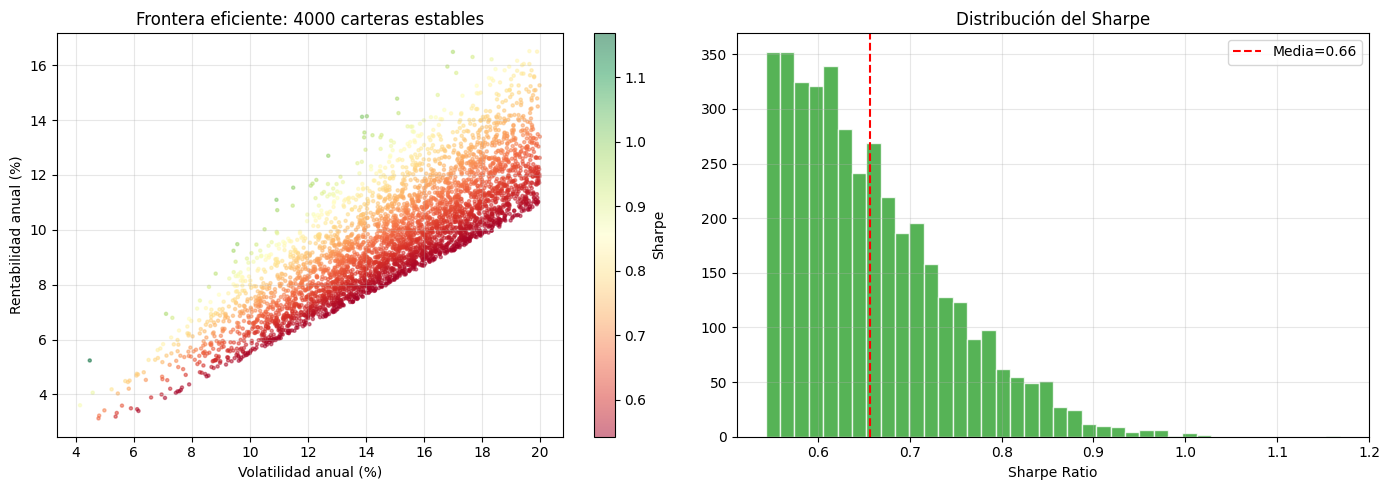

In [7]:
from src.nb02_portfolios import plot_portfolios

fig = plot_portfolios(feat_df, FIG_DIR)
plt.show()

**Interpretación:** El scatter riesgo-rentabilidad muestra la frontera eficiente simulada. Las carteras con mayor Sharpe (verde) aparecen en la parte superior izquierda del espacio (alta rentabilidad, baja volatilidad). El histograma de Sharpe confirma que la mayoría de carteras se concentran entre 0.40 y 0.70, con una cola derecha representando las carteras de mayor calidad.

## 7. Guardado de outputs

In [8]:
from src.nb02_portfolios import save_outputs

save_outputs(feat_df, composition, port_returns, PROCESSED_DIR)
print(f'\n✓ NB02 COMPLETO — {len(feat_df)} carteras estables (Sharpe≥0.30, Vol≤20%)')

Saved: portfolios_features.parquet | portfolios_composition.parquet | portfolios_returns.parquet

✓ NB02 COMPLETO — 4000 carteras estables (Sharpe≥0.30, Vol≤20%)
